# Import libraries

In [1]:
import stim
from pyzx import *
import networkx as nx
import matplotlib.pyplot as plt

# Define some examples of stabilizer codes 


In [2]:
steane = {
        "n": 7,
        "k": 1,
        "stabilizers": [
            "IIIXXXX",
            "IXXIIXX",
            "XIXIXIX",
            "IIIZZZZ",
            "IZZIIZZ",
            "ZIZIZIZ"
        ]
}
five_qubit = {
        "n" : 5,
        "k": 1,
        "stabilizers": [
            "XZZXI",
            "IXZZX",
            "XIXZZ",
            "ZXIXZ"
        ]
}


shor_code = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "ZZIIIIIII",
        "IZZIIIIII",
        "IIIZZIIII",
        "IIIIZZIII",
        "IIIIIIZZI",
        "IIIIIIIZZ",
        "XXXXXXIII",
        "IIIXXXXXX"
    ]
}
r3x3 = {
    "n": 9,
    "k": 1,
    "stabilizers": [
        "IZZIIIIII",
        "ZZIZZIIII",
        "IIIIIIZZI",
        "IIIIZZIZZ",
        "XIIXIIIII",
        "IXXIXXIII",
        "IIIXXIXXI",
        "IIIIIXIIX"
    ]
}
t2x2 = {
    "n": 8,
    "k": 2,
    "stabilizers": [
        "XXIXIIIX",
        "IIXIXXXI",
        "IIIXXXIX",
        "ZIZZZIII",
        "IZZZIZII",
        "ZIIIZIZZ"
    ]
}
t3x3 = {
    "n": 18,
    "k": 2,
    "stabilizers": [
        "XXIIXIIIIIIIIIIIXI",
        "IXXIIXIIIIIIIIIIIX",
        "IIIXIIXIXXIIIIIIII",
        "IIIIXIXXIIXIIIIIII",
        "IIIIIXIXXIIXIIIIII",
        "IIIIIIIIIXIIXIXXII",
        "IIIIIIIIIIXIXXIIXI",
        "IIIIIIIIIIIXIXXIIX",
        "IZIIZZIZIIIIIIIIII",
        "IIZZIZIIZIIIIIIIII",
        "IIIIIIZIIZZIZIIIII",
        "IIIIIIIZIIZZIZIIII",
        "IIIIIIIIZZIZIIZIII",
        "ZIIIIIIIIIIIZIIZZI",
        "IZIIIIIIIIIIIZIIZZ",
        "IIZIIIIIIIIIIIZZIZ"
    ]
}


In [3]:
def display_code(name, stabilizers):
    u = stabilizers_to_UGR(stabilizers)

    G = nx.Graph()

    adj_list = u.adj
    print(u.inputs)

    for x in range(len(adj_list)):
        if x in u.inputs:
            print(x)
            G.add_node(x, color="#4e598c")
        else:
            G.add_node(x, color="#ff8c42")

    for u, neighbors in enumerate(adj_list):
        for v in neighbors:
            G.add_edge(u, v)

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=144)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]


    nx.draw(G, pos, 
            node_color=node_colors, 
            node_size=600, 
            font_weight='bold')

    # plt.title("Graph from Index-Based Adjacency List")
    plt.savefig(f"plots/{name}")
    plt.show()





## Steane code

[0]
0


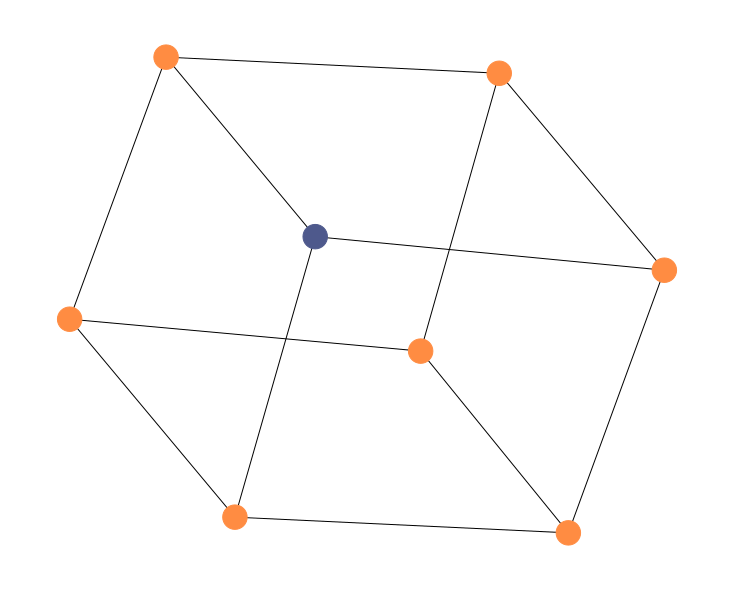

In [4]:
display_code("steane",steane["stabilizers"])

## Shor code

[0]
0


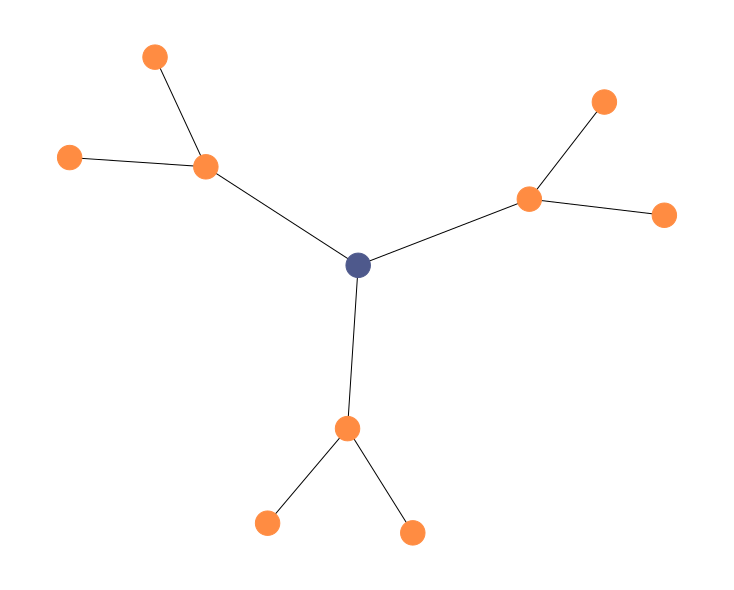

In [5]:
display_code("shor",shor_code["stabilizers"])

## 5 qubit code

[0]
0


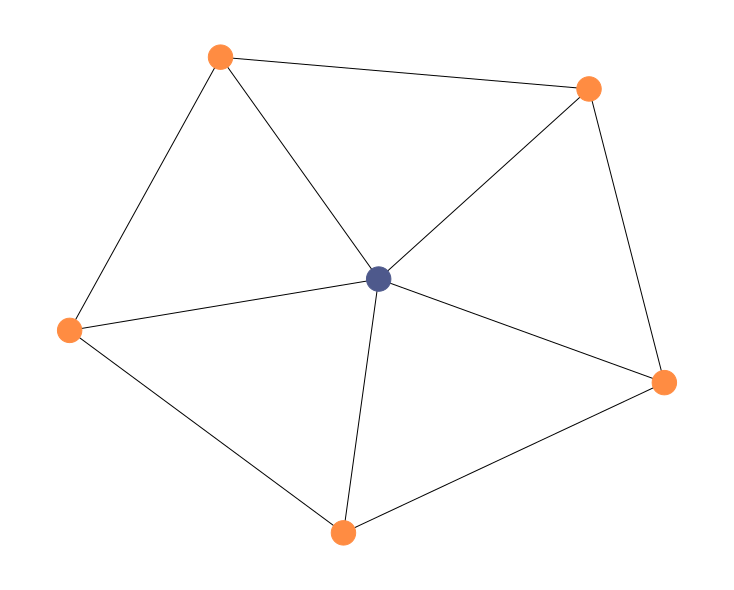

In [6]:
display_code("five_qubit",five_qubit["stabilizers"])

## Rotated surface code 3x3

[0]
0


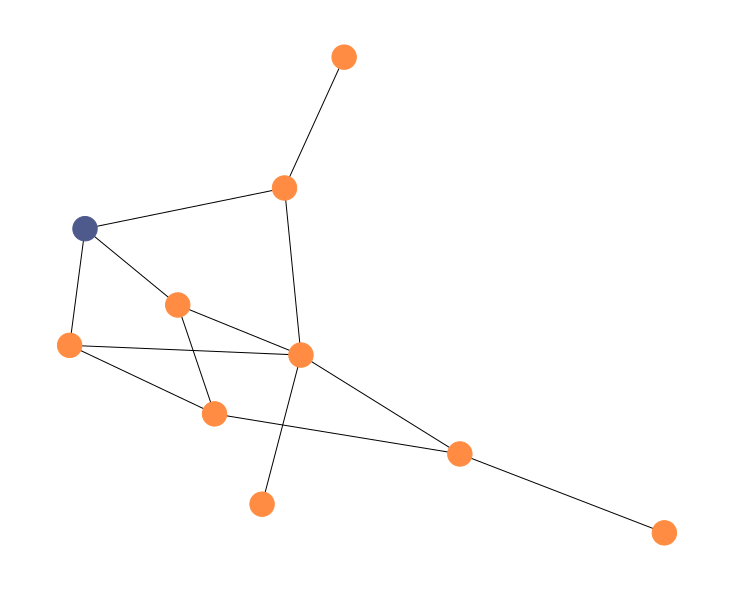

In [7]:
display_code("rotated",r3x3["stabilizers"])

## Toric Code 2x2

[0, 1]
0
1


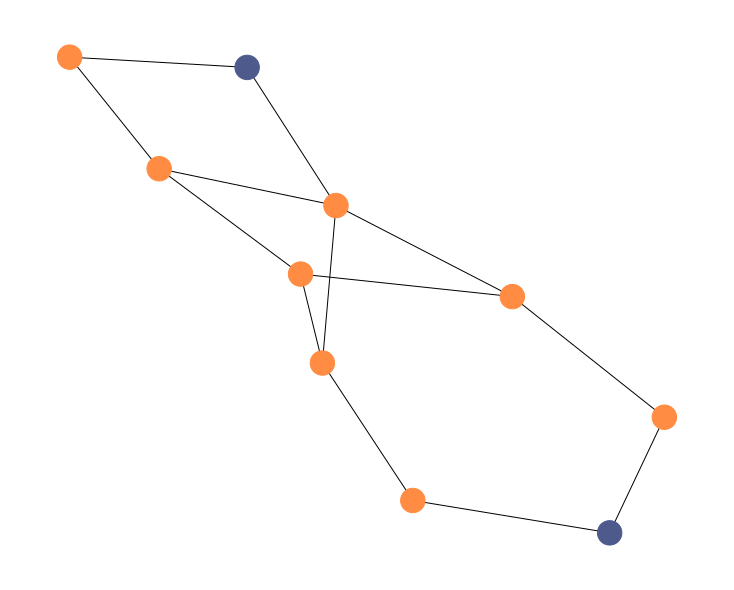

In [8]:
display_code("toric2x2", t2x2["stabilizers"])

## Toric Code 3x3

[0, 1]
0
1


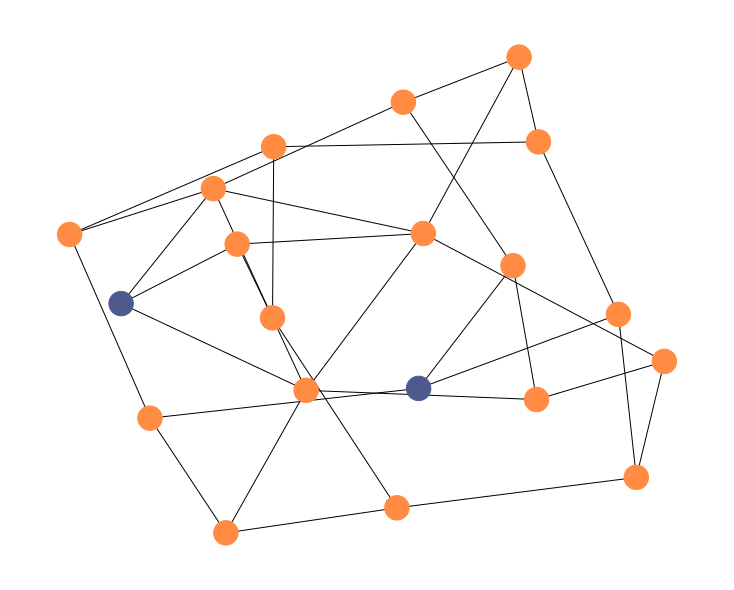

In [9]:
display_code("toric3x3",t3x3["stabilizers"])

Stabilizer list for stabilizers_to_UGR():
[
    "XXIXIIIIIXIXIIIXII",
    "IXXIXIIIIXXIIIIIXI",
    "XIXIIXIIIIXXIIIIIX",
    "IIIXXIXIIXIIXIXIII",
    "IIIIXXIXIIXIXXIIII",
    "IIIXIXIIXIIXIXXIII",
    "XIIIIIXXIIIIXIIXIX",
    "IXIIIIIXXIIIIXIXXI",
    "IIXIIIXIXIIIIIXIXX",
    "ZZIZIIIIIZIZIIIZII",
    "IZZIZIIIIZZIIIIIZI",
    "ZIZIIZIIIIZZIIIIIZ",
    "IIIZZIZIIZIIZIZIII",
    "IIIIZZIZIIZIZZIIII",
    "IIIZIZIIZIIZIZZIII",
    "ZIIIIIZZIIIIZIIZIZ",
    "IZIIIIIZZIIIIZIZZI",
    "IIZIIIZIZIIIIIZIZZ",
]
[0, 1, 2, 3]
0
1
2
3


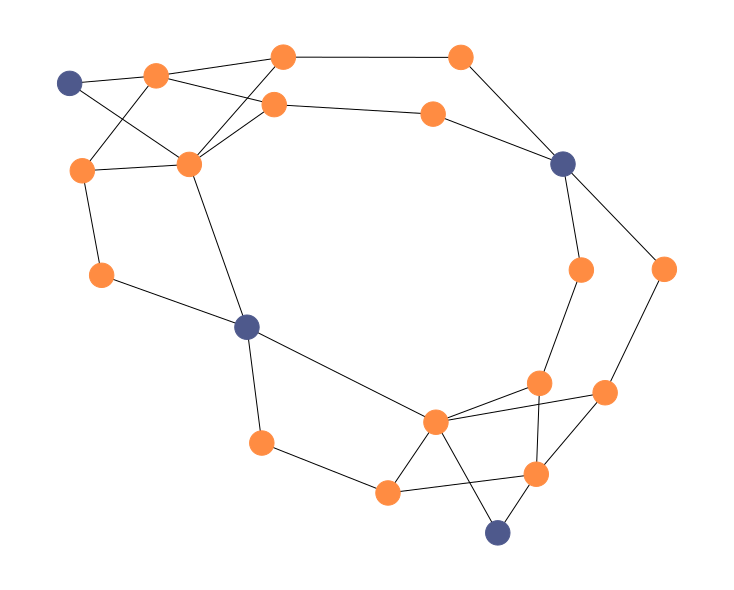

In [10]:
import numpy as np

def generate_bb_code_stabilizers(L=3):
    """
    Generates the X and Z stabilizers for a small Bivariate Bicycle (qLDPC) code.
    The code operates on 2 * L^2 physical qubits.
    """
    N_half = L * L
    I = np.eye(N_half, dtype=int)
    
    # 1. Create the X and Y cyclic shift matrices for an L x L periodic grid
    Sx = np.zeros((N_half, N_half), dtype=int)
    Sy = np.zeros((N_half, N_half), dtype=int)
    
    for i in range(L):
        for j in range(L):
            idx = i * L + j
            
            # Shift along the x-axis (with periodic boundary)
            idx_x = i * L + ((j + 1) % L)
            Sx[idx, idx_x] = 1
            
            # Shift along the y-axis (with periodic boundary)
            idx_y = ((i + 1) % L) * L + j
            Sy[idx, idx_y] = 1
            
    # 2. Define the polynomials A and B
    # Using A = 1 + x + y
    A = (I + Sx + Sy) % 2
    
    # Using B = 1 + x^2 + y^2
    Sx2 = np.dot(Sx, Sx) % 2
    Sy2 = np.dot(Sy, Sy) % 2
    B = (I + Sx2 + Sy2) % 2
    
    # 3. Construct the CSS Parity Check Matrices
    # H_X = [A, B]
    Hx = np.hstack((A, B))
    
    # H_Z = [B^T, A^T] 
    # This guarantees H_X * H_Z^T = AB + BA = 0 mod 2
    Hz = np.hstack((B.T, A.T))
    
    # 4. Convert the binary matrices into Pauli strings
    stabilizers = []
    
    # Generate X-type Pauli strings
    for row in Hx:
        pauli_string = "".join(["X" if val == 1 else "I" for val in row])
        # Only add non-trivial stabilizers
        if "X" in pauli_string: 
            stabilizers.append(pauli_string)
            
    # Generate Z-type Pauli strings
    for row in Hz:
        pauli_string = "".join(["Z" if val == 1 else "I" for val in row])
        if "Z" in pauli_string:
            stabilizers.append(pauli_string)
            
    return stabilizers

# Execute and print the results
bb_stabilizers = generate_bb_code_stabilizers(L=3)

print("Stabilizer list for stabilizers_to_UGR():")
print("[")
for s in bb_stabilizers:
    print(f'    "{s}",')
print("]")

my = [
"XXXXIIIIIIIIIIII",
"IIIIXXXXIIIIIIII",
"IIIIIIIIXXXXIIII",
"IIIIIIIIIIIIXXXX",
"XXIIXXIIIIIIIIII",
"IIIIIIIIXXIIXXII",
"ZZZZIIIIIIIIIIII",
"IIIIZZZZIIIIIIII",
"IIIIIIIIZZZZIIII",
"IIIIIIIIIIIIZZZZ",
"ZZIIIIIIZZIIIIII",
"IIIIZZIIIIIIZZII"
]

display_code("bb",my)